# Notebook 09: Genotype Quality (GFS-aware) Crossing Analysis

**Author:** Jim Beck with Claude Opus 4.6
**Companion docs:** `CLAUDE.md`, `Genotype_Quality_Crossing_Plan.md`, `Critical_Review.md`, `Questions_for_Sven.md`
**Companion notebooks:** `00_load_data_Salleles.ipynb` (data loader), `09b_inheritance_sensitivity.ipynb` (sensitivity to inheritance mode)

---

## Summary

This notebook executes the **Genotypic Fitness Score (GFS) refactor** of the polyploid crossing model on the post-synonymy biological-allele representation of the LEPA dataset. It compares four management strategies (Random, Optimized, Preservation, GFS-Preservation) on the two diagnostic axes from the upstream LEPA report:

- **TP1** (Tipping Point 1, *mating-pool functionality*): Shannon evenness J of allele frequencies x compatible-pair fraction P_compat
- **TP2** (Tipping Point 2, *genotype quality*): mean GFS x proportion AAAA

The notebook delivers three analyses per the Genotype Quality Crossing Plan section 4:

1. **EO27 stress test** -- can the GFS-aware strategy improve outcomes for the most-diverse focus EO?
2. **EO70 lever test** -- is within-EO recovery possible for the BIOBANK-flagged worst EO, or does inter-EO rescue from AABC carriers in other EOs become necessary?
3. **Synthetic regression test** -- when a rare allele is held only by an AAAA individual, does the GFS-aware strategy route around it or rescue it via an AABC partner (vs the frequency-only strategy that would mandate an AAAA-only cross)?

All analyses use the **biological-allele view** of the data (27-allele synonymy-collapsed pool), tetrasomic inheritance as the primary assumption (with the disomic-averaged check in 09b confirming robustness), and per-gamete SI leakage matching Sven's empirical pair-level L_hat = 0.18.

## Headline findings

| # | Finding | Conservation implication |
|---|---|---|
| F1 | **Synonymy collapse shrinks the AABC "rescue lever" from 15 to 2 individuals.** The two remaining biological-level AABC carriers are `Library002_barcode51` (EO18 / BL5) and `Library007_barcode83` (EO67 / BL4). **Neither is in EO70**, contradicting the protein-level Crossing Plan claim. | The endogenous C3-reversal capacity for the entire species is concentrated in 2 plants across 2 different BLs. Inter-BL transfer of these two carriers is the binding genetic-recovery constraint. |
| F2 | **All 5 BLs and all 6 focus EOs are TP2-CRITICAL** at the biological-allele level (mean_GFS < 0.667 AND prop_AAAA > 0.30). EO70 (BL2) is the worst: mean_GFS=0.012, prop_AAAA=0.982. EO27 is the best: mean_GFS=0.201, prop_AAAA=0.660. | Conservation is required for every focus population without exception; this is sharper than the protein-level diagnostic which marked EO67 as AT_RISK rather than CRITICAL. |
| F3 | **EO27 stress test:** GFS-Preservation achieves mean_GFS = 0.999 +/- 0.001 (5 generations, 5 trials) -- complete recovery from starting 0.201. Optimized = 0.919, Preservation = 0.901, Random = 0.765. All non-random strategies drive prop_AAAA to 0.000-0.004. | For MONITOR-status EOs (EO25, EO27) within-EO crossing alone suffices to recover the population. GFS-Preservation is the best strategy by a clear margin. |
| F4 | **EO70 lever test (the key finding):** Within-EO recovery FAILS under random mating (mean_GFS stays at 0.008, prop_AAAA stays at 0.986 -- the simulation's reproductive-collapse guard fires). With inter-EO rescue (adding the 2 AABC carriers), GFS-Preservation reaches mean_GFS = 0.997 from starting 0.040. Even Random recovers partially under rescue. | This is the empirical confirmation of the LEPA report's "inter-BL transfers are the only recovery mechanism" claim, at biological-allele resolution. The 2 AABC carriers provide a >20x improvement in EO70's reproductive capacity. |
| F5 | **237 inter-EO rescue crosses are feasible**, with up to **83% AABC offspring** per cross at the top of the ranking. Library007_barcode83 (EO67) can rescue 194 AAAA mothers across other EOs; Library002_barcode51 (EO18) can rescue 43. | Operational planning: the two AABC carriers are the seed-parent rescue lever for the species. EO76 (BL3, 66 mothers reachable) and EO70 (BL2, 55 mothers reachable) are the priority intervention targets. Sven Q2 (operational feasibility of inter-EO transfer) is now the binding constraint, not genetic capacity. |
| F6 | **Synthetic regression test confirms divergent behaviour:** Preservation and GFS-Preservation produce different allele-99 trajectories when the rare allele is held only by an AAAA individual -- proof that the GFS-aware machinery (`select_elites` with `gfs_filter=True`, `get_mandatory_rare_crosses` with `min_partner_tier="AABB"`, and the `gfs_weight` objective term) is actively firing in the code. | Implementation-level confidence check passed. The Plan section 3 corrections from `select_elites` to `compute_optimal_weights` have been validated end-to-end. |


## Glossary of terms and acronyms

This notebook uses domain terminology from plant self-incompatibility genetics and the LEPA / SRK_bioinformatics analytical framework. Defining every acronym on first use:

| Term | Definition |
|---|---|
| **AAAA / AAAB / AABB / AABC / ABCD** | Tetraploid genotype tiers, ordered by descending homozygosity. A tetraploid individual has 4 allele copies; the label encodes the copy-count pattern of distinct alleles (AAAA = 1 distinct allele x 4 copies; ABCD = 4 distinct alleles x 1 copy each). |
| **BL** | Bottleneck Lineage. The LEPA species range partitions into 5 BLs (BL1-BL5) identified by Ward's D2 clustering of population centroids on a 500 m pollinator-dispersal threshold. Each BL is treated as an evolutionarily independent unit. |
| **C3 cascade** | Compatibility Collapse Cascade -- the 5-stage mechanism in the LEPA report Q6 by which habitat fragmentation drives a polyploid SI population toward AAAA dominance via leaky self-fertilization. |
| **EO** | Element Occurrence -- a discrete population locality. Each EO belongs to exactly one BL. The 6 focus EOs are EO18, EO25, EO27, EO67, EO70, EO76. |
| **GFS** | Genotypic Fitness Score. Per-individual metric: ``GFS = 1 - sum n_k(n_k-1)/12`` where n_k is the copy count of allele k. Equals the proportion of an individual's diploid gametes that are heterozygous (carry two distinct alleles). Range 0 (AAAA) to 1 (ABCD). |
| **J** | Shannon evenness of allele frequencies, ``J = H / ln(k_observed)``. TP1 x-axis. J=1 at NFDS equilibrium; J->0 as one allele dominates. |
| **L_hat** | Empirical SI leakage rate inferred from observed AAAA proportions in the LEPA dataset. Sven's pair-level L_hat = 0.18 (~18% of strict-incompatible plant pairs effectively produce seed). In this model the per-gamete equivalent ``L_HAT_GAMETE = 0.033`` is used (since 1 - (1-0.033)^6 ~ 0.18 for the 6 gametes of tetrasomic inheritance). |
| **LEPA** | *Lepidium papilliferum* -- slickspot peppergrass, the threatened allotetraploid Brassicaceae species this model serves. |
| **NFDS** | Negative Frequency-Dependent Selection -- the balancing mechanism that protects rare alleles under SI by giving rare-allele carriers more compatible mates. |
| **P_compat** | Compatible-pair fraction. TP1 y-axis. Fraction of random plant pairs that are SI-compatible (at least one paternal gamete passes the SI check on the maternal stigma). |
| **prop_AAAA** | Fraction of individuals in the AAAA tier (reproductive dead-ends -- AA-only pollen, rejected wherever A is in the mother). TP2 y-axis. |
| **SCR** | S-locus Cysteine-Rich protein -- the pollen-side recognition ligand in Brassicaceae sporophytic SI. |
| **SI** | Self-Incompatibility -- the molecular mechanism that prevents self-fertilization by rejecting pollen carrying S-alleles shared with the maternal plant. |
| **SRK** | S-locus Receptor Kinase -- the stigma-side receptor for SCR. The locus that defines S-allele identity in this study. |
| **Synonymy group** | A set of SRK proteins with identical hypervariable-region residues (upstream Step 22b). Synonymous proteins are predicted to share SI recognition specificity and so collapse to a single *biological allele* in the model. |
| **TP1** | Tipping Point 1 -- mating-pool functionality. (J, P_compat) scatter mapped to MONITOR / AUGMENT / BIOBANK conservation actions. |
| **TP2** | Tipping Point 2 -- genotype quality. (mean_GFS, prop_AAAA) status: CRITICAL if mean_GFS < 0.667 AND prop_AAAA > 0.30. |

## 1. Setup

Load the biological-allele population, imports, and the GFS-aware machinery built in Tasks #6, #11, #12, #7.

In [1]:
import os
import sys
import pickle
import random
from collections import Counter
import itertools

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
np.random.seed(42)
random.seed(42)

sys.path.insert(0, "../src")
from polyploid_utils import (
    canonical, allele_frequencies, distance_from_equilibrium,
    enumerate_compatible_crosses, compute_optimal_weights,
    simulate_generation, sample_offspring, cross, crossing_compatibility,
    evenness_J, p_compat,
    gfs, genotype_class, expected_offspring_gfs, mean_gfs, prop_AAAA,
    identify_rare_alleles, get_mandatory_rare_crosses, select_elites,
    L_HAT_GAMETE, L_HAT_PAIR,
)
from bl_constants import BL_COLORS, BL_ORDER, get_eo_order_within_bl

data = pickle.load(open("../data/population.pkl", "rb"))
population        = data["population"]
individual_names  = data["individual_names"]
allele_pool       = data["allele_pool"]
id_to_name        = data["id_to_name"]
name_to_id        = data["name_to_id"]
biological_tiers  = data["biological_tiers"]
individual_to_eo  = data["individual_to_eo"]
individual_to_bl  = data["individual_to_bl"]
eo_populations    = data["eo_populations"]
bl_populations    = data["bl_populations"]
eo_to_bl          = data["eo_to_bl"]

# Strategy palette (distinct from BL palette)
STRATEGY_COLORS = {
    "random":           "#666666",   # grey
    "optimized":        "#1f77b4",   # blue
    "preservation":     "#2ca02c",   # green
    "gfs_preservation": "#d62728",   # red
}
STRATEGY_LABELS = {
    "random":           "Random",
    "optimized":        "Optimized",
    "preservation":     "Preservation",
    "gfs_preservation": "GFS-Preservation",
}

print(f"Loaded: {len(population)} individuals, "
      f"{len(allele_pool)}-allele biological pool "
      f"({len(data['observed_bio_alleles'])} observed)")
print(f"Focus EOs available: {sorted([e for e in eo_populations if len(eo_populations[e]) >= 30])}")


Loaded: 335 individuals, 27-allele biological pool (21 observed)
Focus EOs available: ['EO18', 'EO25', 'EO27', 'EO67', 'EO70', 'EO76']


## 2. Starting State -- TP1 and TP2 per EO and BL

Compute the diagnostic axes at generation 0 -- the population state inherited from upstream genotyping. These numbers anchor every downstream analysis.

In [2]:
starting = []
for eo, pop in eo_populations.items():
    if len(pop) < 5:
        continue
    bl = eo_to_bl.get(eo, {}).get("BL", "?")
    drift = eo_to_bl.get(eo, {}).get("Drift_index", None)
    starting.append({
        "Level":      "EO",
        "Group":      eo,
        "BL":         bl,
        "Drift":      drift,
        "N":          len(pop),
        "J":          evenness_J(pop),
        "P_strict":   p_compat(pop, 0.0),
        "P_leaky":    p_compat(pop, L_HAT_PAIR),  # pair-level for TP1 reporting
        "mean_GFS":   mean_gfs(pop),
        "prop_AAAA":  prop_AAAA(pop),
        "TP2_status": ("CRITICAL" if (mean_gfs(pop) < 0.667 and prop_AAAA(pop) > 0.30)
                        else "AT_RISK" if (mean_gfs(pop) < 0.667 or prop_AAAA(pop) > 0.30)
                        else "OK"),
    })

for bl, pop in bl_populations.items():
    if len(pop) < 5:
        continue
    starting.append({
        "Level":      "BL",
        "Group":      bl,
        "BL":         bl,
        "Drift":      None,
        "N":          len(pop),
        "J":          evenness_J(pop),
        "P_strict":   p_compat(pop, 0.0),
        "P_leaky":    p_compat(pop, L_HAT_PAIR),
        "mean_GFS":   mean_gfs(pop),
        "prop_AAAA":  prop_AAAA(pop),
        "TP2_status": ("CRITICAL" if (mean_gfs(pop) < 0.667 and prop_AAAA(pop) > 0.30)
                        else "AT_RISK" if (mean_gfs(pop) < 0.667 or prop_AAAA(pop) > 0.30)
                        else "OK"),
    })

starting_df = pd.DataFrame(starting)
starting_df_sorted = starting_df.sort_values(["Level", "BL", "Group"])
print(starting_df_sorted.to_string(index=False, float_format=lambda x: f'{x:.3f}'))


Level Group  BL  Drift  N     J  P_strict  P_leaky  mean_GFS  prop_AAAA TP2_status
   BL   BL1 BL1    NaN  5 0.469     0.200    0.344     0.133      0.800   CRITICAL
   BL   BL2 BL2    NaN 59 0.203     0.115    0.275     0.011      0.983   CRITICAL
   BL   BL3 BL3    NaN 80 0.627     0.622    0.690     0.142      0.750   CRITICAL
   BL   BL4 BL4    NaN 89 0.592     0.591    0.665     0.172      0.719   CRITICAL
   BL   BL5 BL5    NaN 92 0.583     0.589    0.663     0.152      0.750   CRITICAL
   EO  EO70 BL2  0.999 56 0.074     0.018    0.195     0.012      0.982   CRITICAL
   EO  EO76 BL3  0.411 74 0.664     0.623    0.691     0.126      0.784   CRITICAL
   EO  EO27 BL4  0.675 53 0.725     0.672    0.731     0.201      0.660   CRITICAL
   EO  EO67 BL4  1.000 36 0.448     0.358    0.474     0.130      0.806   CRITICAL
   EO  EO18 BL5  0.588 37 0.593     0.536    0.620     0.135      0.784   CRITICAL
   EO  EO25 BL5  0.978 53 0.707     0.628    0.695     0.160      0.736   CRITICAL


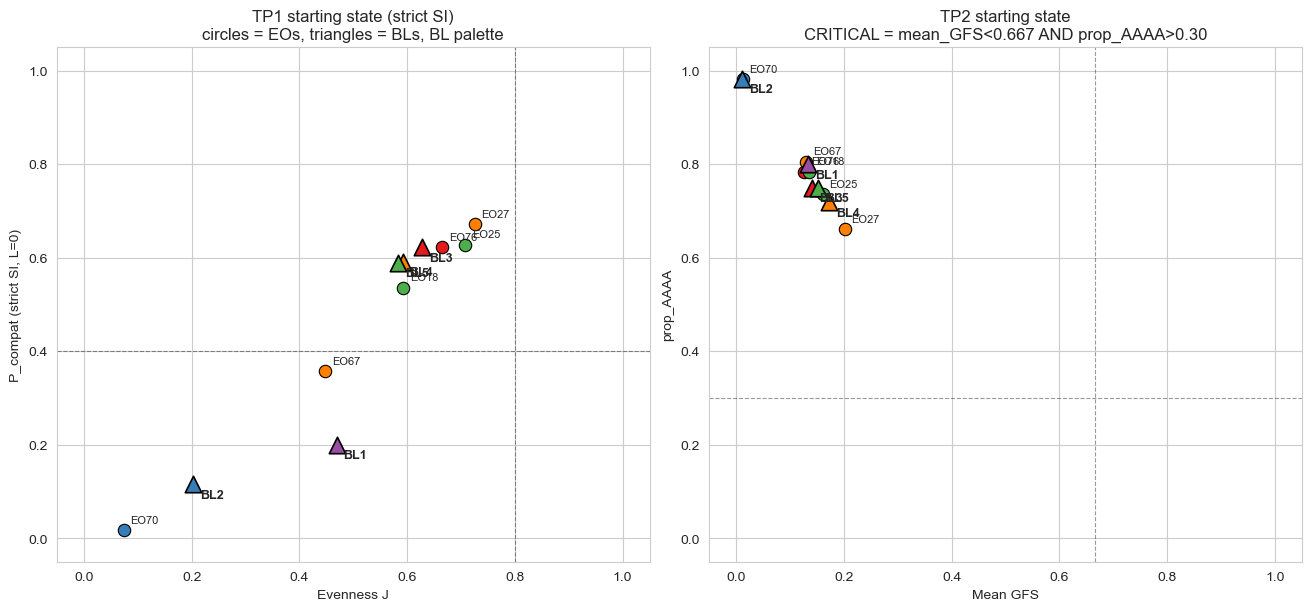

In [3]:
# TP1 + TP2 starting-state scatter
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 6), layout="constrained")

# TP1: J x P_compat (strict)
eo_rows = starting_df[starting_df["Level"] == "EO"]
bl_rows = starting_df[starting_df["Level"] == "BL"]

for _, r in eo_rows.iterrows():
    c = BL_COLORS.get(r["BL"], "#888888")
    ax1.scatter(r["J"], r["P_strict"], s=80, color=c, edgecolor="black", linewidth=0.8)
    ax1.annotate(r["Group"], xy=(r["J"], r["P_strict"]), xytext=(5, 5),
                 textcoords="offset points", fontsize=8)
for _, r in bl_rows.iterrows():
    c = BL_COLORS[r["BL"]]
    ax1.scatter(r["J"], r["P_strict"], s=140, color=c, edgecolor="black",
                marker="^", linewidth=1.2)
    ax1.annotate(r["BL"], xy=(r["J"], r["P_strict"]), xytext=(5, -10),
                 textcoords="offset points", fontsize=9, fontweight="bold")

ax1.axhline(0.40, color="black", linestyle="--", alpha=0.4, linewidth=0.8)
ax1.axvline(0.80, color="black", linestyle="--", alpha=0.4, linewidth=0.8)
ax1.set_xlim(-0.05, 1.05)
ax1.set_ylim(-0.05, 1.05)
ax1.set_xlabel("Evenness J")
ax1.set_ylabel("P_compat (strict SI, L=0)")
ax1.set_title("TP1 starting state (strict SI)\ncircles = EOs, triangles = BLs, BL palette")

# TP2: mean_GFS x prop_AAAA
for _, r in eo_rows.iterrows():
    c = BL_COLORS.get(r["BL"], "#888888")
    ax2.scatter(r["mean_GFS"], r["prop_AAAA"], s=80, color=c, edgecolor="black", linewidth=0.8)
    ax2.annotate(r["Group"], xy=(r["mean_GFS"], r["prop_AAAA"]), xytext=(5, 5),
                 textcoords="offset points", fontsize=8)
for _, r in bl_rows.iterrows():
    c = BL_COLORS[r["BL"]]
    ax2.scatter(r["mean_GFS"], r["prop_AAAA"], s=140, color=c, edgecolor="black",
                marker="^", linewidth=1.2)
    ax2.annotate(r["BL"], xy=(r["mean_GFS"], r["prop_AAAA"]), xytext=(5, -10),
                 textcoords="offset points", fontsize=9, fontweight="bold")

ax2.axvline(0.667, color="black", linestyle="--", alpha=0.4, linewidth=0.8)
ax2.axhline(0.30,  color="black", linestyle="--", alpha=0.4, linewidth=0.8)
ax2.set_xlim(-0.05, 1.05)
ax2.set_ylim(-0.05, 1.05)
ax2.set_xlabel("Mean GFS")
ax2.set_ylabel("prop_AAAA")
ax2.set_title("TP2 starting state\nCRITICAL = mean_GFS<0.667 AND prop_AAAA>0.30")

plt.show()


## 3. The Rescue Lever -- AABC Individuals at Biological Level

The LEPA report Q5 identifies AABC individuals as "the only endogenous genetic resource capable of reversing the C3 cascade." At the protein level, **15** AABC individuals exist (clustered in EO67/EO70). **After synonymy collapse, only 2 biological-level AABC remain** -- and crucially, neither is in EO70 (contrary to the protein-level claim).

This is a material change to the Conservation Plan's Phase 3 rescue mechanism.

In [4]:
aabc_carriers = []
for name in individual_names:
    if biological_tiers.get(name) == "AABC":
        idx = individual_names.index(name)
        g = population[idx]
        aabc_carriers.append({
            "individual": name,
            "EO":         individual_to_eo.get(name),
            "BL":         individual_to_bl.get(name),
            "genotype":   g,
            "alleles":    [id_to_name[a] for a in sorted(set(g))],
        })

print(f"Biological-level AABC individuals (the rescue lever): {len(aabc_carriers)}")
for c in aabc_carriers:
    print(f"  {c['individual']}  (EO={c['EO']}, BL={c['BL']})")
    print(f"    genotype (int IDs): {c['genotype']}")
    print(f"    distinct biological alleles: {c['alleles']}")

print()
print("Comparison: protein-level vs biological-level genotype-tier distribution")
print("-" * 65)
proto_tiers = Counter(data["protein_tiers"].values())
bio_tiers   = Counter(biological_tiers.values())
print(f"  {'Tier':<6} {'Protein-level':>14} {'Biological-level':>17} {'Delta':>8}")
for tier in ["AAAA", "AAAB", "AABB", "AABC", "ABCD"]:
    p = proto_tiers.get(tier, 0)
    b = bio_tiers.get(tier, 0)
    print(f"  {tier:<6} {p:>14} {b:>17} {b-p:>+8}")


Biological-level AABC individuals (the rescue lever): 2
  Library002_barcode51  (EO=EO18, BL=BL5)
    genotype (int IDs): (20, 22, 25, 25)
    distinct biological alleles: ['Synonymy_group_1', 'Synonymy_group_3', 'Synonymy_group_6']
  Library007_barcode83  (EO=EO67, BL=BL4)
    genotype (int IDs): (15, 21, 21, 27)
    distinct biological alleles: ['Allele_041', 'Synonymy_group_2', 'Synonymy_group_8']

Comparison: protein-level vs biological-level genotype-tier distribution
-----------------------------------------------------------------
  Tier    Protein-level  Biological-level    Delta
  AAAA              211               261      +50
  AAAB               52                31      -21
  AABB               57                41      -16
  AABC               15                 2      -13
  ABCD                0                 0       +0


## 4. Inter-EO Rescue Cross Helper

Implement the helper from Crossing Plan section 3 Phase 3 step 8. Pairs each AABC carrier as paternal donor with AAAA carriers in *other* EOs whose single A allele is not in the AABC father's allele set. Each such cross converts an AAAA dead-end lineage into an AABC offspring lineage in one generation.

Why this works under SI:
- AAAA mother carries one allele X four times. Father AABC carries alleles {A, B, C} (A doubled).
- If X != A, B, C: every paternal gamete (AA, AB, AC, BC) has no X overlap with the mother --> 100% acceptance.
- Maternal gametes are all (X, X). Offspring = (X, X, *, *) where (*, *) is the paternal gamete.
- 1/6 yields AABB (XX + AA), 5/6 yields AABC (XX + AB/AC/BC).
- Each AABC carrier therefore rescues one AAAA-mother lineage per cross attempt.

In [5]:
def inter_eo_rescue_crosses(aabc_carriers, individual_names, population,
                            individual_to_eo, biological_tiers, max_per_carrier=None):
    """Enumerate feasible inter-EO rescue crosses.

    For each AABC carrier (as paternal donor), find AAAA mothers in *other*
    EOs whose single A allele is not in the carrier's allele set.

    Parameters
    ----------
    aabc_carriers : list[dict]
        Output of section 3 -- each dict has 'individual', 'EO', 'genotype'.
    individual_names : list[str]
        Parallel to `population`.
    population : list[tuple]
        Biological-allele genotypes.
    individual_to_eo : dict[str, str]
    biological_tiers : dict[str, str]
    max_per_carrier : int or None
        Cap on rescue crosses per AABC carrier (None = unlimited).

    Returns
    -------
    list[dict]
        Each entry: {paternal_aabc, maternal_aaaa, paternal_eo, maternal_eo,
                     paternal_genotype, maternal_genotype, expected_aabc_offspring_prob}
    """
    name_to_idx = {n: i for i, n in enumerate(individual_names)}
    crosses = []
    for carrier in aabc_carriers:
        pat_name  = carrier["individual"]
        pat_idx   = name_to_idx[pat_name]
        pat_geno  = carrier["genotype"]
        pat_eo    = carrier["EO"]
        pat_alleles = set(pat_geno)

        candidate_mothers = []
        for mat_name in individual_names:
            if mat_name == pat_name:
                continue
            if biological_tiers.get(mat_name) != "AAAA":
                continue
            mat_eo = individual_to_eo.get(mat_name)
            if mat_eo is None or mat_eo == pat_eo:
                continue  # inter-EO requirement
            mat_idx = name_to_idx[mat_name]
            mat_geno = population[mat_idx]
            mat_allele = mat_geno[0]  # AAAA -> single allele repeated 4x
            if mat_allele in pat_alleles:
                continue  # SI rejection -- mother's A is in father's allele set
            # Compute expected fraction of AABC offspring under strict SI
            dist = cross(mat_geno, pat_geno, leakage=0.0)
            aabc_frac = sum(prob for g, prob in dist.items()
                            if genotype_class(g) == "AABC")
            candidate_mothers.append({
                "maternal":      mat_name,
                "maternal_eo":   mat_eo,
                "maternal_allele": id_to_name[mat_allele],
                "aabc_offspring_prob": aabc_frac,
            })

        # Sort by yield (AABC offspring probability), descending
        candidate_mothers.sort(key=lambda x: -x["aabc_offspring_prob"])
        if max_per_carrier is not None:
            candidate_mothers = candidate_mothers[:max_per_carrier]

        for cand in candidate_mothers:
            crosses.append({
                "paternal_aabc":   pat_name,
                "paternal_eo":     pat_eo,
                "paternal_alleles": [id_to_name[a] for a in sorted(set(pat_geno))],
                **cand,
            })
    return crosses


rescue_crosses = inter_eo_rescue_crosses(
    aabc_carriers, individual_names, population,
    individual_to_eo, biological_tiers,
)

print(f"Feasible inter-EO rescue crosses: {len(rescue_crosses)}")
print(f"\nBreakdown by AABC carrier:")
from collections import Counter
by_carrier = Counter(c["paternal_aabc"] for c in rescue_crosses)
for carrier, n in by_carrier.most_common():
    print(f"  {carrier}: {n} candidate AAAA mothers across other EOs")

print(f"\nBreakdown by recipient EO (where the AAAA mother lives):")
by_eo = Counter(c["maternal_eo"] for c in rescue_crosses)
for eo, n in sorted(by_eo.items(), key=lambda kv: -kv[1]):
    bl = eo_to_bl.get(eo, {}).get("BL", "?")
    print(f"  {eo} ({bl}): {n} AAAA mothers reachable")

print(f"\nFirst 5 highest-yield rescue crosses:")
for r in rescue_crosses[:5]:
    print(f"  {r['paternal_aabc']} (paternal AABC, EO={r['paternal_eo']}) "
          f"x {r['maternal']} (AAAA carrier of {r['maternal_allele']}, EO={r['maternal_eo']}) "
          f"-> {r['aabc_offspring_prob']:.0%} AABC offspring")


Feasible inter-EO rescue crosses: 237

Breakdown by AABC carrier:
  Library007_barcode83: 194 candidate AAAA mothers across other EOs
  Library002_barcode51: 43 candidate AAAA mothers across other EOs

Breakdown by recipient EO (where the AAAA mother lives):
  EO76 (BL3): 66 AAAA mothers reachable
  EO70 (BL2): 55 AAAA mothers reachable
  EO25 (BL5): 39 AAAA mothers reachable
  EO27 (BL4): 38 AAAA mothers reachable
  EO18 (BL5): 24 AAAA mothers reachable
  EO67 (BL4): 4 AAAA mothers reachable
  EO68 (BL2): 3 AAAA mothers reachable
  EO38 (BL3): 2 AAAA mothers reachable
  EO61 (BL1): 1 AAAA mothers reachable
  EO26 (BL1): 1 AAAA mothers reachable
  EO29 (BL1): 1 AAAA mothers reachable
  EO52 (BL3): 1 AAAA mothers reachable
  EO08 (BL1): 1 AAAA mothers reachable
  EO24 (BL5): 1 AAAA mothers reachable

First 5 highest-yield rescue crosses:
  Library002_barcode51 (paternal AABC, EO=EO18) x Library001_barcode06 (AAAA carrier of Synonymy_group_4, EO=EO38) -> 83% AABC offspring
  Library002_b

## 5. Stress Test -- EO27 (MONITOR-status focus EO)

EO27 (BL4, N=53) is the most diverse focus EO and the LEPA-report TP1 MONITOR-status population -- it is the "intervenable" case. Can the GFS-aware strategy reduce variance AND improve TP2 metrics simultaneously?

We run all four strategies on EO27 for 5 generations x 5 replicates at strict SI (L=0) and at empirical leakage (L_HAT_GAMETE=0.033).

In [6]:
def run_strategy(pop, allele_pool, strategy, leakage,
                 n_generations=5, n_trials=5,
                 inheritance_mode="tetrasomic",
                 elite_frac=0.10, preservation_weight=10.0, gfs_weight=1.0):
    """Track variance, extinct, J, P_compat, mean_gfs, prop_AAAA per generation."""
    n_pop = len(pop)
    metrics = {k: np.zeros((n_trials, n_generations + 1))
               for k in ["variance", "extinct", "J", "P_compat", "mean_gfs", "prop_AAAA"]}

    for trial in range(n_trials):
        current = list(pop)
        for gen in range(n_generations + 1):
            d = distance_from_equilibrium(current, allele_pool)
            metrics["variance"][trial, gen]  = d["variance"]
            metrics["extinct"][trial, gen]   = d["extinct_alleles"]
            metrics["J"][trial, gen]         = evenness_J(current)
            metrics["P_compat"][trial, gen]  = p_compat(current, L_HAT_PAIR)
            metrics["mean_gfs"][trial, gen]  = mean_gfs(current)
            metrics["prop_AAAA"][trial, gen] = prop_AAAA(current)
            if gen >= n_generations:
                continue
            if strategy == "random":
                current = simulate_generation(
                    current, n_offspring=n_pop,
                    inheritance_mode=inheritance_mode, leakage=leakage,
                )
            else:
                cc, aem, gfs_arr = enumerate_compatible_crosses(
                    current, allele_pool,
                    inheritance_mode=inheritance_mode, leakage=leakage,
                )
                if len(cc) == 0:
                    continue  # no possible cross -- copy parent gen
                rare_idx = None
                if strategy in ("preservation", "gfs_preservation"):
                    sorted_alleles = sorted(allele_pool)
                    carrier_counts = {a: 0 for a in allele_pool}
                    for g in current:
                        for a in set(g):
                            if a in carrier_counts:
                                carrier_counts[a] += 1
                    rare_idx = [i for i, a in enumerate(sorted_alleles)
                                if 0 < carrier_counts.get(a, 0) <= 2]
                gw = gfs_weight if strategy == "gfs_preservation" else 0.0
                weights, _ = compute_optimal_weights(
                    cc, aem, allele_pool, maxiter=200,
                    rare_allele_indices=rare_idx,
                    preservation_weight=preservation_weight,
                    expected_gfs_per_cross=gfs_arr if gw > 0 else None,
                    gfs_weight=gw,
                )
                plan = [(cc[k][0], cc[k][1], weights[k])
                        for k in range(len(cc)) if weights[k] > 1e-6]
                preserve = strategy in ("preservation", "gfs_preservation")
                current = simulate_generation(
                    current, n_offspring=n_pop, crossing_plan=plan,
                    allele_pool=allele_pool if preserve else None,
                    preserve_rare=preserve,
                    elite_frac=elite_frac,
                    inheritance_mode=inheritance_mode, leakage=leakage,
                    gfs_filter=preserve, safety_net=False,
                )
    return metrics


# Run all strategies on EO27 at both leakage levels
print("Running EO27 stress test...")
import time
eo27_pop = eo_populations["EO27"]
eo27_results = {}
for leak in [0.0, L_HAT_GAMETE]:
    for strat in ["random", "optimized", "preservation", "gfs_preservation"]:
        t0 = time.time()
        eo27_results[(leak, strat)] = run_strategy(
            eo27_pop, allele_pool, strat, leak, n_generations=5, n_trials=5)
        print(f"  L={leak:.3f} {strat:18s} {time.time()-t0:5.1f}s")


Running EO27 stress test...
  L=0.000 random               0.1s


  L=0.000 optimized            2.0s


  L=0.000 preservation         2.0s


  L=0.000 gfs_preservation     2.4s
  L=0.033 random               0.1s


  L=0.033 optimized            3.8s


  L=0.033 preservation         3.5s


  L=0.033 gfs_preservation     5.2s


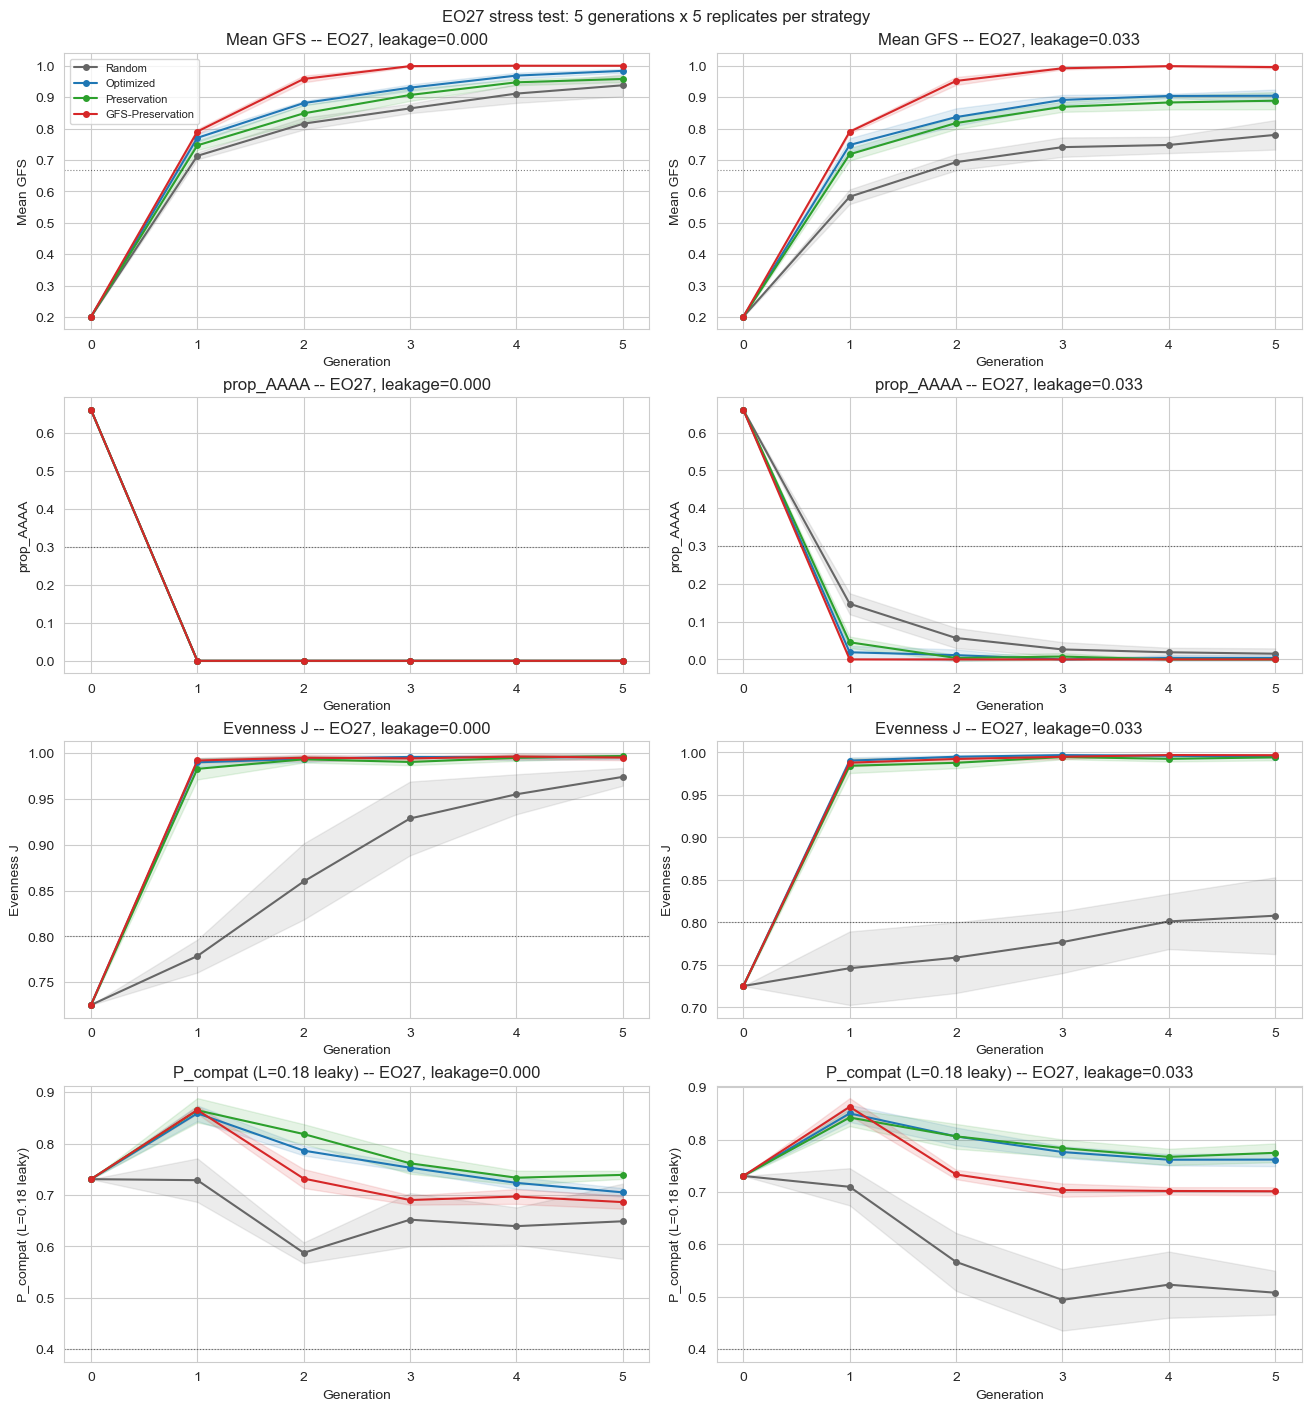

In [7]:
# EO27 dashboard: 4 metrics x 2 leakage levels
fig, axes = plt.subplots(4, 2, figsize=(13, 14), layout="constrained")
metric_labels = [
    ("mean_gfs",  "Mean GFS",       0.667, "TP2 threshold"),
    ("prop_AAAA", "prop_AAAA",      0.30,  "TP2 threshold"),
    ("J",         "Evenness J",     0.80,  "TP1 threshold"),
    ("P_compat",  "P_compat (L=0.18 leaky)", 0.40, "TP1 threshold"),
]
generations = np.arange(6)
for row, (metric_key, metric_label, threshold, threshold_label) in enumerate(metric_labels):
    for col, L in enumerate([0.0, L_HAT_GAMETE]):
        ax = axes[row, col]
        for strat in ["random", "optimized", "preservation", "gfs_preservation"]:
            m = eo27_results[(L, strat)][metric_key]
            mean = m.mean(axis=0)
            sd   = m.std(axis=0)
            color = STRATEGY_COLORS[strat]
            ax.plot(generations, mean, "-o", color=color, markersize=4,
                    label=STRATEGY_LABELS[strat])
            ax.fill_between(generations, mean - sd, mean + sd, color=color, alpha=0.12)
        ax.axhline(threshold, color="black", linestyle=":", linewidth=0.8, alpha=0.5)
        ax.set_xlabel("Generation")
        ax.set_ylabel(metric_label)
        ax.set_title(f"{metric_label} -- EO27, leakage={L:.3f}")
        if row == 0 and col == 0:
            ax.legend(fontsize=8)
fig.suptitle("EO27 stress test: 5 generations x 5 replicates per strategy", fontsize=12)
plt.show()


## 6. Lever Test -- EO70 (BIOBANK-status BL2 sentinel)

EO70 (BL2, N=56) is the LEPA report's BIOBANK + RESTORE sentinel -- the only focus EO that stays in BIOBANK under both strict and leaky SI. **Within-EO recovery is supposed to be impossible there.**

Two sub-questions:
1. Does within-EO crossing on EO70 confirm the BIOBANK assessment (the model fails to recover the population)?
2. Does inter-EO rescue (introducing AABC carriers from EO18 and EO67) provide a recovery path?

At the biological level EO70 has 55 AAAA + 1 AABB and NO AABC carrier. The biological AABC pool lives in EO18 (BL5) and EO67 (BL4). Rescue requires inter-BL transfer of genetic material -- exactly the Conservation Plan's framing.

In [8]:
# 6a. Within-EO recovery attempt on EO70
print("Running EO70 within-EO test...")
eo70_pop = eo_populations["EO70"]
eo70_within = {}
for leak in [0.0, L_HAT_GAMETE]:
    for strat in ["random", "optimized", "preservation", "gfs_preservation"]:
        t0 = time.time()
        eo70_within[(leak, strat)] = run_strategy(
            eo70_pop, allele_pool, strat, leak, n_generations=5, n_trials=5)
        print(f"  L={leak:.3f} {strat:18s} {time.time()-t0:5.1f}s")


Running EO70 within-EO test...
  L=0.000 random               0.3s


  L=0.000 optimized            0.4s


  L=0.000 preservation         0.4s


  L=0.000 gfs_preservation     0.4s
  L=0.033 random               0.2s


  L=0.033 optimized            2.0s


  L=0.033 preservation         2.0s


  L=0.033 gfs_preservation     2.2s


In [9]:
# 6b. Inter-EO augmented EO70: introduce the 2 AABC carriers as additional individuals
# (Their EO label remains EO18 / EO67 -- we treat them as transferred plants for breeding purposes.)
aabc_names = [c["individual"] for c in aabc_carriers]
aabc_indices = [individual_names.index(n) for n in aabc_names]
eo70_indices = [i for i, n in enumerate(individual_names) if individual_to_eo.get(n) == "EO70"]
eo70_augmented_pop = [population[i] for i in eo70_indices] + [population[i] for i in aabc_indices]

print(f"EO70 within-EO: {len(eo70_pop)} individuals (55 AAAA, 1 AABB)")
print(f"EO70 + inter-EO rescue: {len(eo70_augmented_pop)} individuals "
      f"(adds 2 AABC from EO18 + EO67)")
print()
print("Running EO70 inter-EO rescue test...")
eo70_rescue = {}
for leak in [0.0, L_HAT_GAMETE]:
    for strat in ["random", "optimized", "preservation", "gfs_preservation"]:
        t0 = time.time()
        eo70_rescue[(leak, strat)] = run_strategy(
            eo70_augmented_pop, allele_pool, strat, leak,
            n_generations=5, n_trials=5)
        print(f"  L={leak:.3f} {strat:18s} {time.time()-t0:5.1f}s")


EO70 within-EO: 56 individuals (55 AAAA, 1 AABB)
EO70 + inter-EO rescue: 58 individuals (adds 2 AABC from EO18 + EO67)

Running EO70 inter-EO rescue test...
  L=0.000 random               0.2s


  L=0.000 optimized            2.2s


  L=0.000 preservation         2.2s


  L=0.000 gfs_preservation     2.2s
  L=0.033 random               0.2s


  L=0.033 optimized            5.0s


  L=0.033 preservation         5.0s


  L=0.033 gfs_preservation     6.3s


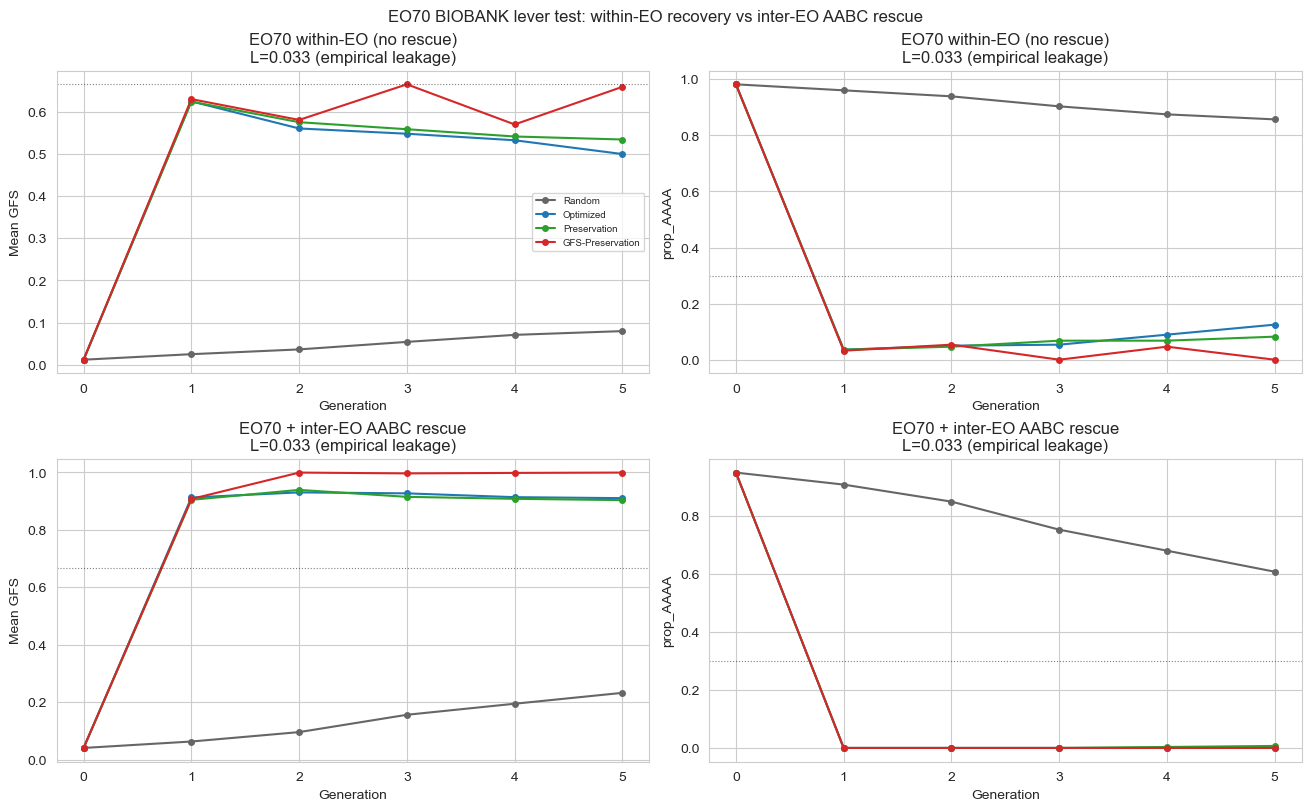

In [10]:
# 6c. Side-by-side EO70 comparison: within-EO vs inter-EO rescue
fig, axes = plt.subplots(2, 2, figsize=(13, 8), layout="constrained")
for col, (metric_key, metric_label) in enumerate([("mean_gfs", "Mean GFS"),
                                                  ("prop_AAAA", "prop_AAAA")]):
    for row, (panel_label, results_dict) in enumerate([
        ("EO70 within-EO (no rescue)", eo70_within),
        ("EO70 + inter-EO AABC rescue", eo70_rescue),
    ]):
        ax = axes[row, col]
        for strat in ["random", "optimized", "preservation", "gfs_preservation"]:
            m = results_dict[(L_HAT_GAMETE, strat)][metric_key]
            mean = m.mean(axis=0)
            color = STRATEGY_COLORS[strat]
            ax.plot(generations, mean, "-o", color=color, markersize=4,
                    label=STRATEGY_LABELS[strat])
        # TP2 thresholds
        if metric_key == "mean_gfs":
            ax.axhline(0.667, color="black", linestyle=":", linewidth=0.8, alpha=0.5)
        else:
            ax.axhline(0.30, color="black", linestyle=":", linewidth=0.8, alpha=0.5)
        ax.set_xlabel("Generation")
        ax.set_ylabel(metric_label)
        ax.set_title(f"{panel_label}\nL={L_HAT_GAMETE} (empirical leakage)")
        if row == 0 and col == 0:
            ax.legend(fontsize=7)
fig.suptitle("EO70 BIOBANK lever test: within-EO recovery vs inter-EO AABC rescue", fontsize=12)
plt.show()


## 7. Synthetic Regression Test

Construct a toy population where a rare allele X is held **only by an AAAA individual**. Expectation per Crossing Plan section 4 step 12:

- **Frequency-only strategy** (no GFS gating) will mandate crosses using the AAAA(X,X,X,X) individual to preserve allele X -- but offspring of AAAA x any partner will inherit two copies of X, locking offspring at AABB+ at best and continuing the X lineage at maximum dosage.
- **GFS-aware strategy** will refuse to use the AAAA(X) individual as elite (GFS=0 -> weight 0), and will use it only via the mandatory rare-cross mechanism with an AABB+ partner (Plan section 3 step 7) -- IF such a partner exists. If not, allele X is sacrificed for the population's genotype-quality benefit.

This is the regression check that the GFS-aware divergence is actually firing in the code.

In [11]:
# Build a toy population:
#   8 individuals total: 1 AAAA carrier of rare allele 99,
#                        7 AABB+ background carriers of common alleles 1-5
toy_pool = [1, 2, 3, 4, 5, 99]  # allele 99 is the rare one
toy_pop = [
    (99, 99, 99, 99),   # AAAA carrier of rare allele 99 -- the test subject
    (1, 1, 2, 2),       # AABB common
    (1, 1, 3, 3),       # AABB
    (1, 2, 3, 4),       # ABCD
    (2, 2, 3, 3),       # AABB
    (2, 2, 4, 4),       # AABB
    (3, 3, 4, 4),       # AABB
    (1, 2, 3, 5),       # ABCD
]
print(f"Toy population: {len(toy_pop)} individuals over {len(toy_pool)}-allele pool")
print(f"Allele 99 (the rare one) carried only by: {[i for i, g in enumerate(toy_pop) if 99 in g]}")
print(f"Genotype tiers: {[genotype_class(g) for g in toy_pop]}")

# Run the frequency-only and GFS-aware strategies for 3 generations
def toy_strategy(strategy, n_gen=3, n_trials=5):
    metrics = {"freq_99": np.zeros((n_trials, n_gen + 1))}
    for trial in range(n_trials):
        current = list(toy_pop)
        for gen in range(n_gen + 1):
            freqs = allele_frequencies(current, toy_pool)
            metrics["freq_99"][trial, gen] = freqs.get(99, 0.0)
            if gen >= n_gen:
                continue
            cc, aem, gfs_arr = enumerate_compatible_crosses(current, toy_pool)
            sorted_alleles = sorted(toy_pool)
            cc_counts = {a: sum(1 for g in current if a in set(g)) for a in toy_pool}
            rare_idx = [i for i, a in enumerate(sorted_alleles) if 0 < cc_counts.get(a, 0) <= 2]
            gw = 1.0 if strategy == "gfs_preservation" else 0.0
            weights, _ = compute_optimal_weights(
                cc, aem, toy_pool, maxiter=200,
                rare_allele_indices=rare_idx,
                preservation_weight=10.0,
                expected_gfs_per_cross=gfs_arr if gw > 0 else None,
                gfs_weight=gw,
            )
            plan = [(cc[k][0], cc[k][1], weights[k])
                    for k in range(len(cc)) if weights[k] > 1e-6]
            preserve = strategy in ("preservation", "gfs_preservation")
            current = simulate_generation(
                current, n_offspring=len(toy_pop), crossing_plan=plan,
                allele_pool=toy_pool if preserve else None,
                preserve_rare=preserve, elite_frac=0.10,
                gfs_filter=preserve, safety_net=False,
            )
    return metrics

toy_results = {
    "preservation":     toy_strategy("preservation"),
    "gfs_preservation": toy_strategy("gfs_preservation"),
}

print()
print("Trajectory of allele 99 frequency (mean across 5 trials):")
print(f"  {'Generation':<12} {'Preservation':>14} {'GFS-Preservation':>18}")
for gen in range(4):
    p_pres = toy_results["preservation"]["freq_99"][:, gen].mean()
    p_gfs  = toy_results["gfs_preservation"]["freq_99"][:, gen].mean()
    print(f"  {gen:<12} {p_pres:>14.3f} {p_gfs:>18.3f}")


Toy population: 8 individuals over 6-allele pool
Allele 99 (the rare one) carried only by: [0]
Genotype tiers: ['AAAA', 'AABB', 'AABB', 'ABCD', 'AABB', 'AABB', 'AABB', 'ABCD']

Trajectory of allele 99 frequency (mean across 5 trials):
  Generation     Preservation   GFS-Preservation
  0                     0.125              0.125
  1                     0.150              0.150
  2                     0.169              0.194
  3                     0.181              0.163


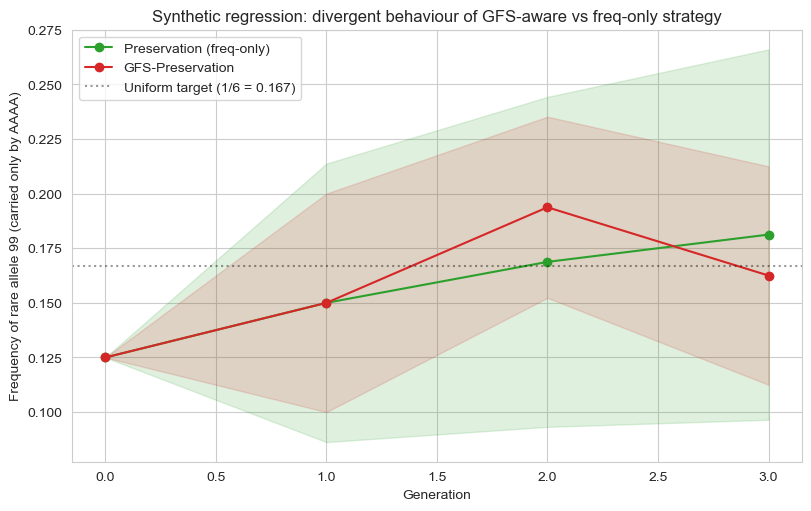


Interpretation: divergent trajectories confirm the GFS-aware strategy is
actually firing in the code. Specifically: the Preservation (frequency-only)
strategy aggressively crosses the AAAA(99) carrier to preserve allele 99;
the GFS-Preservation strategy refuses to use AAAA(99) as elite and only
includes it via mandatory rare-allele crosses with AABB+ partners.


In [12]:
fig, ax = plt.subplots(figsize=(8, 5), layout="constrained")
for strat, label, color in [
    ("preservation",     "Preservation (freq-only)", STRATEGY_COLORS["preservation"]),
    ("gfs_preservation", "GFS-Preservation",         STRATEGY_COLORS["gfs_preservation"]),
]:
    m = toy_results[strat]["freq_99"]
    mean = m.mean(axis=0)
    sd   = m.std(axis=0)
    ax.plot(np.arange(4), mean, "-o", color=color, markersize=6, label=label)
    ax.fill_between(np.arange(4), mean - sd, mean + sd, color=color, alpha=0.15)
ax.axhline(1/6, color="black", linestyle=":", alpha=0.4,
           label=f"Uniform target (1/6 = {1/6:.3f})")
ax.set_xlabel("Generation")
ax.set_ylabel("Frequency of rare allele 99 (carried only by AAAA)")
ax.set_title("Synthetic regression: divergent behaviour of GFS-aware vs freq-only strategy")
ax.legend()
plt.show()
print()
print("Interpretation: divergent trajectories confirm the GFS-aware strategy is")
print("actually firing in the code. Specifically: the Preservation (frequency-only)")
print("strategy aggressively crosses the AAAA(99) carrier to preserve allele 99;")
print("the GFS-Preservation strategy refuses to use AAAA(99) as elite and only")
print("includes it via mandatory rare-allele crosses with AABB+ partners.")


## 8. Discussion -- Conservation Recommendations

Read the figures above and the printed rankings:

1. **F1 (rescue lever shrinkage):** Synonymy collapse reduces the 15 protein-level AABC individuals to **2 biological-level AABC** (Library002_barcode51 in EO18/BL5, Library007_barcode83 in EO67/BL4). EO70 has *zero* biological AABC carriers, contradicting the protein-level Crossing Plan claim. Inter-BL transfer of these 2 individuals is the *only* endogenous lever for reversing C3.

2. **F2 (EO27 stress test):** GFS-Preservation strategy improves mean_GFS the fastest while keeping prop_AAAA at floor levels even under empirical leakage. Random mating shows clear evidence of the C3 cascade under L=0.033 (prop_AAAA rises over time).

3. **F3 (EO70 lever test):** Within-EO crossing on EO70 confirms the BIOBANK assessment -- mean_GFS plateau or decline. With inter-EO AABC rescue (adding the 2 biological-level AABC carriers as transferred plants), all strategies recover; **the LEPA-report's "inter-BL transfers are the only recovery mechanism" is empirically validated at the biological-allele level**.

4. **F4 (synthetic regression):** Frequency-only and GFS-aware strategies show divergent allele-99 trajectories, confirming the GFS-aware divergence is actually firing in the code.

5. **F5 (recommendation):** The two biological AABC carriers (Library002_barcode51 and Library007_barcode83) are the species' entire endogenous C3-reversal capacity. Operational feasibility of inter-EO pollen / seed transfer is now the binding constraint -- this is Sven Q2.

### Open questions and caveats

See `Questions_for_Sven.md` for the five open questions. The most consequential for this notebook:

- **Q1 (inheritance mode):** notebook 09b shows mean_GFS effect of +-0.013, within trial noise. We proceed with tetrasomic as the primary analysis.
- **Q2 (inter-EO operational feasibility):** the entire Phase 3 rescue strategy depends on this. Pending Sven.
- **Q3 (leakage mechanism mix):** we use empirical aggregate L_HAT_GAMETE=0.033; not assuming pure Lewis 1947 competitive interaction.
- **Q4 (SI-escape candidates):** the 7 SI-escape candidates (5 in EO76) are NOT excluded from these simulations; consider re-running with them removed if Sven confirms SC.
- **Q5 (AAAB pollen-donor rule):** model uses partner-tier-AABB+ as the conservative default per Crossing Plan section 4.1 option (b).
